In [1]:
import pandas as pd

In [2]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\ASUS\OneDrive\Desktop\BUS_INSIDE\NOTEBOOKS
['.ipynb_checkpoints', 'lode_DATA.ipynb']


In [3]:
import os

print(os.getcwd())

C:\Users\ASUS\OneDrive\Desktop\BUS_INSIDE\NOTEBOOKS


In [4]:
import os

print(os.listdir("../data"))

['BUS_Insights_Data', 'BUS_Insights_Data.zip']


In [5]:
print(os.listdir("../data/BUS_Insights_Data"))

['data']


In [6]:
print(os.listdir("../data/BUS_Insights_Data/data"))

['customers.csv', 'data_dictionary.csv', 'monthly_targets.csv', 'orders.csv', 'payments.csv', 'products.csv']


In [7]:
customers = pd.read_csv("../data/BUS_Insights_Data/data/customers.csv")

In [8]:
orders = pd.read_csv("../data/BUS_Insights_Data/data/orders.csv")

In [9]:
products = pd.read_csv("../data/BUS_Insights_Data/data/products.csv")

In [10]:
payments = pd.read_csv("../data/BUS_Insights_Data/data/payments.csv")

In [11]:
monthly_targets = pd.read_csv("../data/BUS_Insights_Data/data/monthly_targets.csv")

In [12]:
data_dictionary = pd.read_csv("../data/BUS_Insights_Data/data/data_dictionary.csv")

In [13]:
print("COSTOMERS")
print(customers.shape)
print()

COSTOMERS
(3000, 8)



In [14]:
print("ORDERS")
print(orders.shape)
print()

ORDERS
(20000, 14)



In [15]:
print("PRODUCTS")
print(products.shape)
print()

PRODUCTS
(150, 6)



In [16]:
print("PAYMENTS")
print(payments.shape)
print()

PAYMENTS
(20000, 6)



In [17]:
print("MONTHLY TARGETS")
print(monthly_targets.shape)
print()

MONTHLY TARGETS
(21, 3)



In [18]:
print("DATA DICTIONARY")
print(data_dictionary.shape)

DATA DICTIONARY
(12, 3)


In [19]:
orders.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Product_ID', 'Quantity',
       'Discount', 'Payment_Method', 'Order_Status', 'Channel',
       'Delivery_Days', 'Rating', 'Sales', 'Profit', 'Profit_Margin'],
      dtype='str')

In [20]:
orders.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Discount,Payment_Method,Order_Status,Channel,Delivery_Days,Rating,Sales,Profit,Profit_Margin
0,ORD100000,2026-06-28,CUST10971,PROD1007,3,0.00,Credit Card,Delivered,Mobile App,6,5,207807.6300,38895.097059,0.187169
1,ORD100001,2025-08-11,CUST10003,PROD1122,1,0.10,Cash on Delivery,Delivered,Mobile App,2,4,26714.6190,8785.804034,0.328876
2,ORD100002,2025-06-04,CUST12190,PROD1041,2,0.05,UPI,Delivered,Mobile App,2,3,123227.7490,29566.032183,0.239930
3,ORD100003,2025-12-26,CUST12520,PROD1004,3,0.15,Credit Card,Delivered,Website,7,3,30302.0325,11221.121511,0.370309
4,ORD100004,2025-12-16,CUST12578,PROD1028,1,0.10,Credit Card,Delivered,Website,3,4,45551.0340,10929.083966,0.239931


In [21]:
orders.dtypes

Order_ID              str
Order_Date            str
Customer_ID           str
Product_ID            str
Quantity            int64
Discount          float64
Payment_Method        str
Order_Status          str
Channel               str
Delivery_Days       int64
Rating              int64
Sales             float64
Profit            float64
Profit_Margin     float64
dtype: object

In [22]:
orders["Order_Date"] = pd.to_datetime(orders["Order_Date"])

In [23]:
orders["Order_Date"].dtype

dtype('<M8[us]')

In [24]:
orders.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Product_ID        0
Quantity          0
Discount          0
Payment_Method    0
Order_Status      0
Channel           0
Delivery_Days     0
Rating            0
Sales             0
Profit            0
Profit_Margin     0
dtype: int64

In [25]:
orders.duplicated().sum()

np.int64(0)

In [26]:
orders[["Quantity", "Discount", "Delivery_Days", "Rating", "Sales", "Profit", "Profit_Margin"]].describe()

,Quantity,Discount,Delivery_Days,Rating,Sales,Profit,Profit_Margin
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,1.747800,0.088908,4.495650,3.990900,56159.944191,17729.781309,0.315744
std,0.994909,0.066549,2.289005,1.004275,48888.026733,16430.736638,0.077681
min,1.000000,0.000000,1.000000,1.000000,237.697500,51.396957,0.180019
25%,1.000000,0.050000,2.000000,4.000000,23279.166000,6714.179359,0.248573
50%,1.000000,0.100000,4.000000,4.000000,44029.728000,13148.730958,0.315956
75%,2.000000,0.150000,6.000000,5.000000,72054.650000,23189.611894,0.382319
max,5.000000,0.250000,8.000000,5.000000,346346.050000,129897.022097,0.449996


In [27]:
orders["Payment_Method"].value_counts()

Payment_Method
UPI                 7569
Credit Card         4388
Debit Card          3215
Net Banking         2807
Cash on Delivery    2021
Name: count, dtype: int64

In [28]:
orders["Order_Status"].value_counts()

Order_Status
Delivered    17624
Cancelled     1407
Returned       969
Name: count, dtype: int64

In [29]:
orders["Channel"].value_counts()

Channel
Mobile App     9391
Website        7646
Marketplace    2963
Name: count, dtype: int64

In [30]:
orders["Rating"].value_counts().sort_index()

Rating
1     622
2    1155
3    2980
4    8269
5    6974
Name: count, dtype: int64

In [31]:
print("Start Date:", orders["Order_Date"].min())
print("End Date:", orders["Order_Date"].max())

Start Date: 2025-01-01 00:00:00
End Date: 2026-09-30 00:00:00


In [32]:
orders["Year"] = orders["Order_Date"].dt.year
orders["Month"] = orders["Order_Date"].dt.month
orders["Month_Name"] = orders["Order_Date"].dt.month_name()

In [33]:
orders["Year"].value_counts().sort_index()

Year
2025    11292
2026     8708
Name: count, dtype: int64

In [34]:
orders.groupby(["Year", "Month"])["Order_ID"].count()

Year  Month
2025  1         884
      2         895
      3         969
      4         911
      5         962
      6         938
      7         946
      8        1003
      9         904
      10        950
      11        941
      12        989
2026  1        1051
      2         917
      3        1014
      4         956
      5        1016
      6         929
      7         944
      8         930
      9         951
Name: Order_ID, dtype: int64

In [35]:
monthly_sales = orders.groupby(["Year", "Month"])["Sales"].sum()
monthly_sales

Year  Month
2025  1        5.033004e+07
      2        5.118424e+07
      3        5.392433e+07
      4        5.207034e+07
      5        5.660981e+07
      6        5.126365e+07
      7        5.282865e+07
      8        5.895658e+07
      9        5.247078e+07
      10       5.372483e+07
      11       5.203284e+07
      12       5.370814e+07
2026  1        5.786922e+07
      2        4.880676e+07
      3        5.462688e+07
      4        5.399325e+07
      5        5.613836e+07
      6        5.259146e+07
      7        5.539135e+07
      8        5.221816e+07
      9        5.245922e+07
Name: Sales, dtype: float64

In [36]:
monthly_profit = orders.groupby(["Year", "Month"])["Profit"].sum()
monthly_profit

Year  Month
2025  1        1.598172e+07
      2        1.590391e+07
      3        1.703115e+07
      4        1.645195e+07
      5        1.763264e+07
      6        1.612407e+07
      7        1.688252e+07
      8        1.857586e+07
      9        1.651713e+07
      10       1.688409e+07
      11       1.632495e+07
      12       1.692933e+07
2026  1        1.816901e+07
      2        1.567341e+07
      3        1.749108e+07
      4        1.714334e+07
      5        1.739639e+07
      6        1.675387e+07
      7        1.743198e+07
      8        1.676518e+07
      9        1.653206e+07
Name: Profit, dtype: float64

In [37]:
total_sales = orders["Sales"].sum()
total_profit = orders["Profit"].sum()

profit_margin = (total_profit / total_sales) * 100

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Profit Margin:", round(profit_margin, 2), "%")

Total Sales: 1123198883.823
Total Profit: 354595626.1877284
Profit Margin: 31.57 %


In [38]:
customers.columns

Index(['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'City', 'State',
       'Customer_Segment', 'Signup_Date'],
      dtype='str')

In [39]:
customers.dtypes

Customer_ID           str
Customer_Name         str
Gender                str
Age                 int64
City                  str
State                 str
Customer_Segment      str
Signup_Date           str
dtype: object

In [40]:
customers["Signup_Date"] = pd.to_datetime(customers["Signup_Date"])

In [41]:
customers["Signup_Date"].dtype

dtype('<M8[us]')

In [42]:
customers.isnull().sum()

Customer_ID         0
Customer_Name       0
Gender              0
Age                 0
City                0
State               0
Customer_Segment    0
Signup_Date         0
dtype: int64

In [43]:
customers.duplicated().sum()

np.int64(0)

In [44]:
customers["Customer_Segment"].value_counts()

Customer_Segment
Consumer          1953
Corporate          634
Small Business     413
Name: count, dtype: int64

In [45]:
customers["Gender"].value_counts()

Gender
Male      1489
Female    1453
Other       58
Name: count, dtype: int64

In [46]:
customers["Age"].describe()

count    3000.000000
mean       41.311667
std        14.016705
min        18.000000
25%        29.000000
50%        41.000000
75%        53.000000
max        65.000000
Name: Age, dtype: float64

In [47]:
customers["Age_Group"] = pd.cut(
    customers["Age"],
    bins=[17, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65"]
)

customers["Age_Group"].value_counts().sort_index()

Age_Group
18-25    530
26-35    628
36-45    609
46-55    615
56-65    618
Name: count, dtype: int64

In [48]:
products.columns

Index(['Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Unit_Price',
       'Brand'],
      dtype='str')

In [49]:
products.dtypes

Product_ID          str
Product_Name        str
Category            str
Sub_Category        str
Unit_Price      float64
Brand               str
dtype: object

In [50]:
products.isnull().sum()

Product_ID      0
Product_Name    0
Category        0
Sub_Category    0
Unit_Price      0
Brand           0
dtype: int64

In [51]:
products.duplicated().sum()

np.int64(0)

In [52]:
products["Category"].value_counts()

Category
Home & Kitchen    38
Sports            32
Electronics       29
Fashion           29
Beauty            22
Name: count, dtype: int64

In [53]:
products["Brand"].value_counts()

Brand
Nova      36
UrbanX    33
Apex      30
Vertex    28
Prime     23
Name: count, dtype: int64

In [54]:
sales_data = orders.merge(
    products,
    on="Product_ID",
    how="left")

In [55]:
sales_data.shape

(20000, 22)

In [56]:
sales_data.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Product_ID        0
Quantity          0
Discount          0
Payment_Method    0
Order_Status      0
Channel           0
Delivery_Days     0
Rating            0
Sales             0
Profit            0
Profit_Margin     0
Year              0
Month             0
Month_Name        0
Product_Name      0
Category          0
Sub_Category      0
Unit_Price        0
Brand             0
dtype: int64

In [57]:
category_performance = sales_data.groupby("Category").agg(
    Orders=("Order_ID", "count"),
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
).sort_values("Sales", ascending=False)

category_performance

,Orders,Sales,Profit,Quantity
Category,,,,
Home & Kitchen,5051,2.959667e+08,9.382936e+07,8764
Sports,4270,2.539828e+08,8.015070e+07,7464
Fashion,3954,2.293769e+08,7.247805e+07,6828
Electronics,3758,2.073959e+08,6.509128e+07,6560
Beauty,2967,1.364766e+08,4.304624e+07,5340


In [58]:
top_products = sales_data.groupby(
    ["Product_ID", "Product_Name", "Category"]
).agg(
    Orders=("Order_ID", "count"),
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).sort_values("Sales", ascending=False).head(10)

top_products

,,,Orders,Sales,Profit
Product_ID,Product_Name,Category,,,
PROD1063,Women Fashion Product 63,Fashion,148,1.645944e+07,5.281036e+06
PROD1104,Smartphones Product 104,Electronics,143,1.562249e+07,4.923909e+06
PROD1112,Footwear Product 112,Fashion,151,1.546233e+07,4.844945e+06
PROD1073,Skin Care Product 73,Beauty,143,1.542268e+07,4.671316e+06
PROD1081,Footwear Product 81,Fashion,141,1.502526e+07,4.809135e+06
PROD1041,Laptops Product 41,Electronics,136,1.463492e+07,4.680917e+06
PROD1149,Cricket Product 149,Sports,131,1.397318e+07,4.459279e+06
PROD1007,Decor Product 7,Home & Kitchen,121,1.378111e+07,4.385144e+06
PROD1011,Men Fashion Product 11,Fashion,136,1.315967e+07,4.263729e+06


In [59]:
top_profit_products = sales_data.groupby(
    ["Product_ID", "Product_Name", "Category"]
).agg(
    Orders=("Order_ID", "count"),
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).sort_values("Profit", ascending=False).head(10)

top_profit_products

,,,Orders,Sales,Profit
Product_ID,Product_Name,Category,,,
PROD1063,Women Fashion Product 63,Fashion,148,1.645944e+07,5.281036e+06
PROD1104,Smartphones Product 104,Electronics,143,1.562249e+07,4.923909e+06
PROD1112,Footwear Product 112,Fashion,151,1.546233e+07,4.844945e+06
PROD1081,Footwear Product 81,Fashion,141,1.502526e+07,4.809135e+06
PROD1041,Laptops Product 41,Electronics,136,1.463492e+07,4.680917e+06
PROD1073,Skin Care Product 73,Beauty,143,1.542268e+07,4.671316e+06
PROD1149,Cricket Product 149,Sports,131,1.397318e+07,4.459279e+06
PROD1007,Decor Product 7,Home & Kitchen,121,1.378111e+07,4.385144e+06
PROD1011,Men Fashion Product 11,Fashion,136,1.315967e+07,4.263729e+06


In [60]:
customer_sales = sales_data.merge(
    customers,
    on="Customer_ID",
    how="left")

In [61]:
customer_sales.shape

(20000, 30)

In [62]:
customer_sales.isnull().sum()

Order_ID            0
Order_Date          0
Customer_ID         0
Product_ID          0
Quantity            0
Discount            0
Payment_Method      0
Order_Status        0
Channel             0
Delivery_Days       0
Rating              0
Sales               0
Profit              0
Profit_Margin       0
Year                0
Month               0
Month_Name          0
Product_Name        0
Category            0
Sub_Category        0
Unit_Price          0
Brand               0
Customer_Name       0
Gender              0
Age                 0
City                0
State               0
Customer_Segment    0
Signup_Date         0
Age_Group           0
dtype: int64

In [63]:
top_customers = customer_sales.groupby(
    ["Customer_ID", "Customer_Name", "Customer_Segment"]
).agg(
    Orders=("Order_ID", "count"),
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).sort_values("Sales", ascending=False).head(10)

top_customers

,,,Orders,Sales,Profit
Customer_ID,Customer_Name,Customer_Segment,,,
CUST11100,Kabir Patel,Consumer,13,1.231307e+06,410782.348024
CUST12690,Aarav Jain,Consumer,12,1.226169e+06,349406.755876
CUST12473,Ananya Deshmukh,Consumer,12,1.192521e+06,367262.349203
CUST10300,Isha Mehta,Consumer,14,1.135464e+06,338444.002650
CUST11035,Priya Deshmukh,Consumer,11,1.096857e+06,374347.530749
CUST11386,Rohan Patel,Consumer,13,1.077954e+06,310518.974640
CUST10355,Vivaan Mehta,Consumer,11,1.050648e+06,347650.955744
CUST12825,Ananya Sharma,Corporate,14,1.037466e+06,330238.775193
CUST10481,Arjun Gupta,Consumer,14,1.020347e+06,323064.493810


In [64]:
segment_performance = customer_sales.groupby("Customer_Segment").agg(
    Customers=("Customer_ID", "nunique"),
    Orders=("Order_ID", "count"),
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).sort_values("Sales", ascending=False)

segment_performance

,Customers,Orders,Sales,Profit
Customer_Segment,,,,
Consumer,1948,12949,7.296196e+08,2.302866e+08
Corporate,632,4301,2.428371e+08,7.652260e+07
Small Business,413,2750,1.507421e+08,4.778646e+07


In [65]:
state_performance = customer_sales.groupby("State").agg(
    Customers=("Customer_ID", "nunique"),
    Orders=("Order_ID", "count"),
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).sort_values("Sales", ascending=False)

state_performance

,Customers,Orders,Sales,Profit
State,,,,
Uttar Pradesh,336,2282,1.317960e+08,4.149498e+07
Karnataka,355,2335,1.303740e+08,4.117465e+07
Maharashtra,347,2285,1.298526e+08,4.129154e+07
Gujarat,338,2242,1.286651e+08,3.977550e+07
Madhya Pradesh,351,2341,1.272187e+08,4.017634e+07
Tamil Nadu,310,2153,1.226319e+08,3.877105e+07
Delhi,328,2174,1.210490e+08,3.806800e+07
Rajasthan,315,2096,1.169681e+08,3.742091e+07
West Bengal,313,2092,1.146434e+08,3.642264e+07


In [66]:
payments.columns

Index(['Payment_ID', 'Order_ID', 'Payment_Date', 'Payment_Method', 'Sales',
       'Payment_Status'],
      dtype='str')

In [67]:
payments["Payment_Date"] = pd.to_datetime(payments["Payment_Date"])

In [68]:
payments.isnull().sum()

Payment_ID        0
Order_ID          0
Payment_Date      0
Payment_Method    0
Sales             0
Payment_Status    0
dtype: int64

In [69]:
payments["Payment_Status"].value_counts()

Payment_Status
Successful    18301
Failed         1699
Name: count, dtype: int64

In [70]:
payments["Payment_Method"].value_counts()

Payment_Method
UPI                 7569
Credit Card         4388
Debit Card          3215
Net Banking         2807
Cash on Delivery    2021
Name: count, dtype: int64

In [71]:
payment_performance = payments.groupby("Payment_Method").agg(
    Total_Payments=("Payment_ID", "count"),
    Successful=("Payment_Status", lambda x: (x == "Successful").sum()),
    Failed=("Payment_Status", lambda x: (x == "Failed").sum())
)

payment_performance["Success_Rate_%"] = (
    payment_performance["Successful"]
    / payment_performance["Total_Payments"]
    * 100
).round(2)

payment_performance.sort_values("Success_Rate_%", ascending=False)

,Total_Payments,Successful,Failed,Success_Rate_%
Payment_Method,,,,
Cash on Delivery,2021,1857,164,91.89
UPI,7569,6929,640,91.54
Credit Card,4388,4015,373,91.50
Debit Card,3215,2939,276,91.42
Net Banking,2807,2561,246,91.24


In [73]:
payments['Payment_Date'] = pd.to_datetime(payments['Payment_Date'])

payments['Payment_Month'] = payments['Payment_Date'].dt.to_period('M').astype(str)

monthly_payment = payments.groupby('Payment_Month').agg(
    Total_Payments=('Payment_ID', 'count'),
    Successful=('Payment_Status', lambda x: (x == 'Successful').sum()),
    Failed=('Payment_Status', lambda x: (x == 'Failed').sum())
).reset_index()

monthly_payment['Success_Rate_%'] = (
    monthly_payment['Successful'] /
    monthly_payment['Total_Payments'] * 100
).round(2)

monthly_payment

,Payment_Month,Total_Payments,Successful,Failed,Success_Rate_%
0,2025-01,884,828,56,93.67
1,2025-02,895,804,91,89.83
2,2025-03,969,885,84,91.33
3,2025-04,911,829,82,91.00
4,2025-05,962,891,71,92.62
5,2025-06,938,848,90,90.41
6,2025-07,946,865,81,91.44
7,2025-08,1003,924,79,92.12
8,2025-09,904,822,82,90.93
9,2025-10,950,879,71,92.53


In [74]:
monthly_targets.head()

,Month,Sales_Target,Profit_Target
0,2025-01-01,9000000.0,1500000.0
1,2025-02-01,9450000.0,1600000.0
2,2025-03-01,9900000.0,1700000.0
3,2025-04-01,10350000.0,1800000.0
4,2025-05-01,10800000.0,1900000.0


In [75]:
# Target month ko datetime mein convert karna
monthly_targets["Month"] = pd.to_datetime(monthly_targets["Month"])

# Actual monthly sales & profit
monthly_actual = orders.groupby(
    orders["Order_Date"].dt.to_period("M")
).agg(
    Actual_Sales=("Sales", "sum"),
    Actual_Profit=("Profit", "sum")
).reset_index()

monthly_actual["Month"] = monthly_actual["Order_Date"].dt.to_timestamp()
monthly_actual = monthly_actual.drop(columns=["Order_Date"])

# Targets + Actual merge
target_vs_actual = monthly_targets.merge(
    monthly_actual,
    on="Month",
    how="left"
)

# Achievement %
target_vs_actual["Sales_Achievement_%"] = (
    target_vs_actual["Actual_Sales"] /
    target_vs_actual["Sales_Target"] * 100
).round(2)

target_vs_actual["Profit_Achievement_%"] = (
    target_vs_actual["Actual_Profit"] /
    target_vs_actual["Profit_Target"] * 100
).round(2)

target_vs_actual

,Month,Sales_Target,Profit_Target,Actual_Sales,Actual_Profit,Sales_Achievement_%,Profit_Achievement_%
0,2025-01-01,9000000.0,1500000.0,5.033004e+07,1.598172e+07,559.22,1065.45
1,2025-02-01,9450000.0,1600000.0,5.118424e+07,1.590391e+07,541.63,993.99
2,2025-03-01,9900000.0,1700000.0,5.392433e+07,1.703115e+07,544.69,1001.83
3,2025-04-01,10350000.0,1800000.0,5.207034e+07,1.645195e+07,503.10,914.00
4,2025-05-01,10800000.0,1900000.0,5.660981e+07,1.763264e+07,524.16,928.03
5,2025-06-01,11250000.0,2000000.0,5.126365e+07,1.612407e+07,455.68,806.20
6,2025-07-01,11700000.0,2100000.0,5.282865e+07,1.688252e+07,451.53,803.93
7,2025-08-01,12150000.0,2200000.0,5.895658e+07,1.857586e+07,485.24,844.36
8,2025-09-01,12600000.0,2300000.0,5.247078e+07,1.651713e+07,416.43,718.14
9,2025-10-01,13050000.0,2400000.0,5.372483e+07,1.688409e+07,411.68,703.50


In [76]:
total_sales = orders["Sales"].sum()
total_profit = orders["Profit"].sum()
total_orders = orders["Order_ID"].nunique()
total_customers = customers["Customer_ID"].nunique()

profit_margin = (total_profit / total_sales) * 100

average_order_value = total_sales / total_orders

successful_payments = (payments["Payment_Status"] == "Successful").sum()
total_payments = payments["Payment_ID"].nunique()
payment_success_rate = (successful_payments / total_payments) * 100

cancelled_orders = (orders["Order_Status"] == "Cancelled").sum()
returned_orders = (orders["Order_Status"] == "Returned").sum()

cancel_return_rate = (
    (cancelled_orders + returned_orders) / total_orders
) * 100

final_kpis = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Profit",
        "Profit Margin %",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Payment Success Rate %",
        "Cancel + Return Rate %"
    ],
    "Value": [
        round(total_sales, 2),
        round(total_profit, 2),
        round(profit_margin, 2),
        total_orders,
        total_customers,
        round(average_order_value, 2),
        round(payment_success_rate, 2),
        round(cancel_return_rate, 2)
    ]
})

final_kpis

,KPI,Value
0,Total Sales,1.123199e+09
1,Total Profit,3.545956e+08
2,Profit Margin %,3.157000e+01
3,Total Orders,2.000000e+04
4,Total Customers,3.000000e+03
5,Average Order Value,5.615994e+04
6,Payment Success Rate %,9.151000e+01
7,Cancel + Return Rate %,1.188000e+01


Matplotlib is building the font cache; this may take a moment.


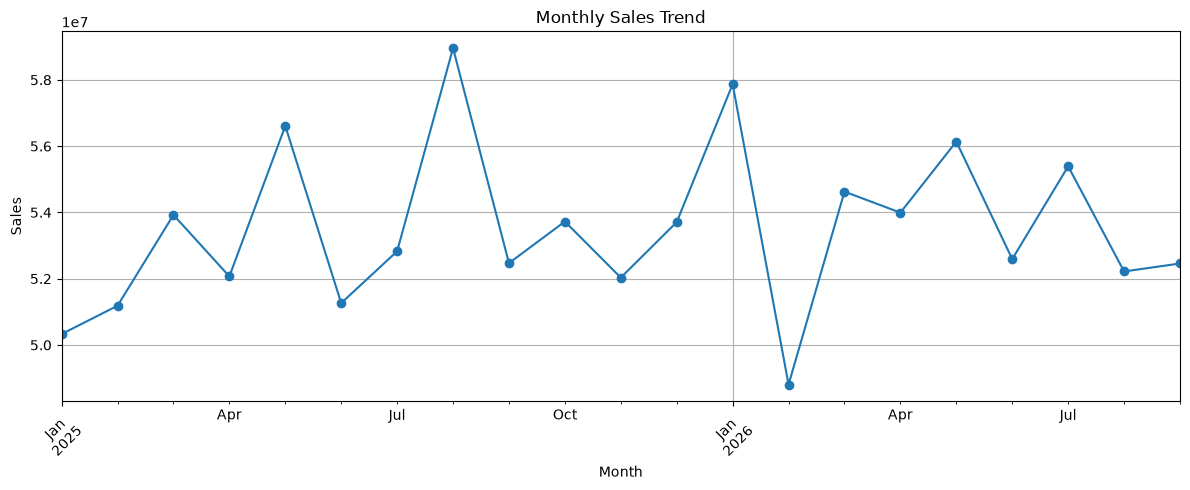

In [78]:
import matplotlib.pyplot as plt

monthly_sales = orders.groupby(
    orders["Order_Date"].dt.to_period("M")
)["Sales"].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [79]:
import matplotlib.pyplot as plt

print("Matplotlib working")

Matplotlib working


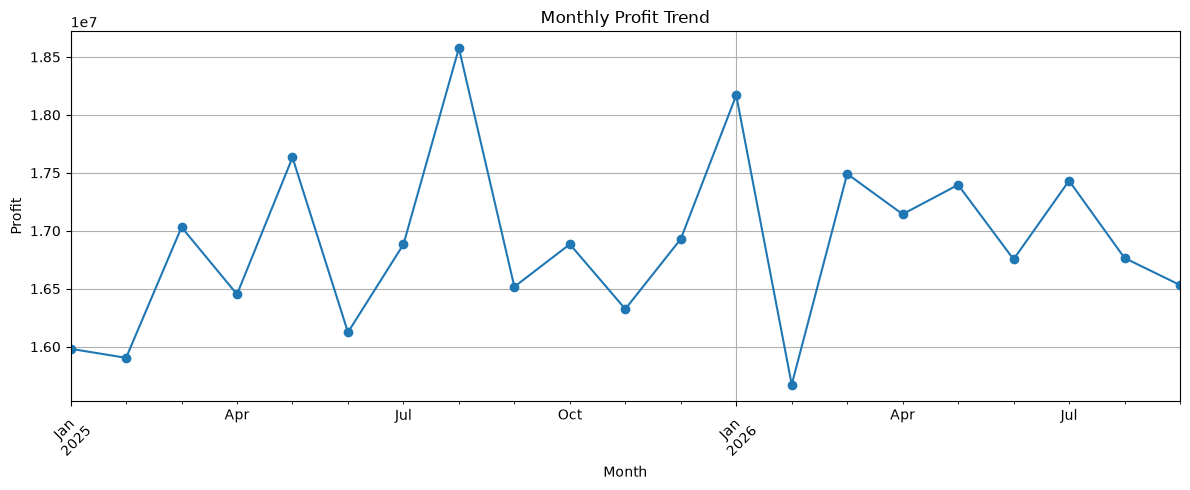

In [80]:
monthly_profit = orders.groupby(
    orders["Order_Date"].dt.to_period("M")
)["Profit"].sum()

plt.figure(figsize=(12, 5))
monthly_profit.plot(kind="line", marker="o")

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

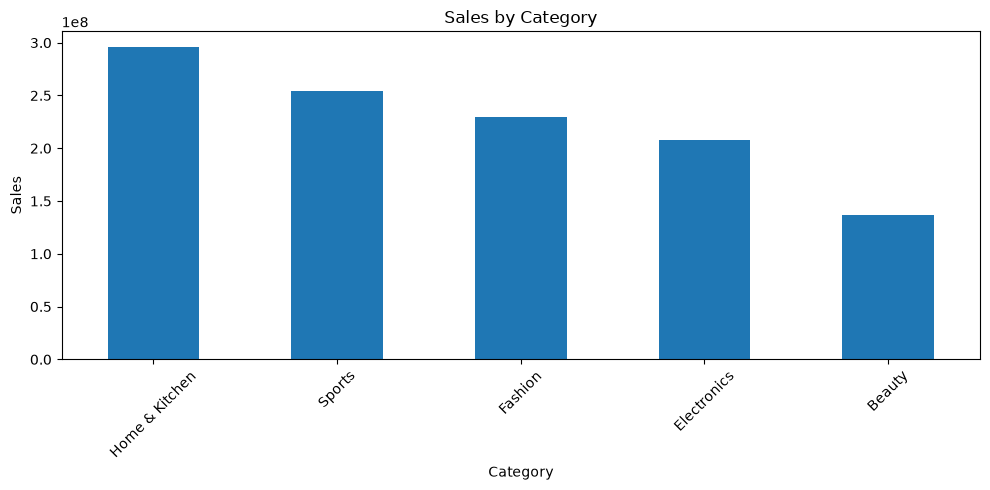

In [81]:
category_sales = sales_data.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

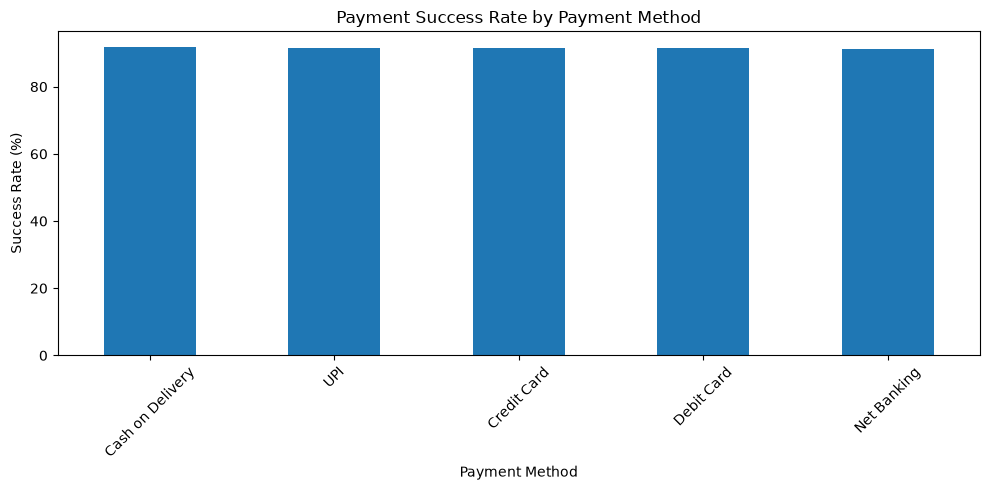

In [82]:
payment_method_performance = payments.groupby("Payment_Method").agg(
    Total=("Payment_ID", "count"),
    Successful=("Payment_Status", lambda x: (x == "Successful").sum())
)

payment_method_performance["Success_Rate_%"] = (
    payment_method_performance["Successful"] /
    payment_method_performance["Total"] * 100
).round(2)

payment_method_performance["Success_Rate_%"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Payment Success Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Success Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

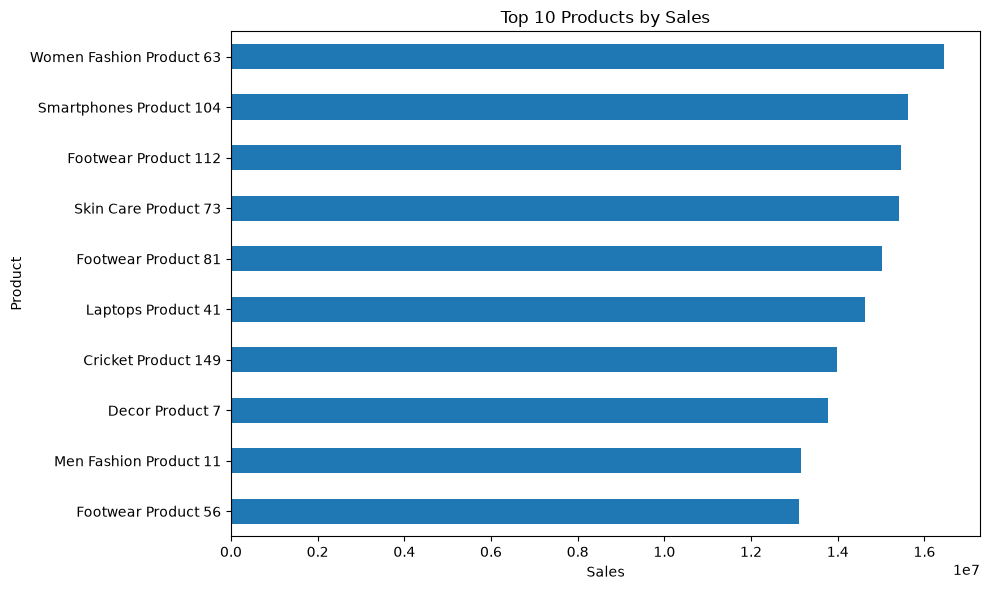

In [83]:
top_products = (
    sales_data.groupby("Product_Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))
top_products.plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()